In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

df = pd.read_csv(os.path.join('..', 'new_data.csv'), index_col=0)
df

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,
1,36,4.0,1,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,0,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,0,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
5,61,3.0,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3384,61,1.0,0,0.0,0.0,0,1,0,217.0,182.0,86.0,26.98,105.0,113.0,0
3385,60,1.0,0,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,0,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0


In [3]:
df['TenYearCHD'].value_counts(normalize=True)

TenYearCHD
0    0.848309
1    0.151691
Name: proportion, dtype: float64

### Handling Class Imbalance with SMOTE

The dataset has roughly 5.5 negative cases for every positive one. Training directly on this would likely produce a model that is biased toward predicting "no disease", and it would look accurate on paper but miss most of the actual at-risk patients, which is the worst possible failure mode in a healthcare setting.

We will use SMOTE (Synthetic Minority Oversampling Technique) to address this. SMOTE works by selecting a minority class sample, finding its k nearest neighbors in the same class, and generating synthetic points along the line segments connecting them.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape

(2341, 14)

In [5]:
from collections import Counter

Counter(y_train)

Counter({0: 1986, 1: 355})

In [6]:
from imblearn.over_sampling import SMOTE

over = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = over.fit_resample(X_train, y_train)

In [7]:
Counter(y_train_smote)

Counter({0: 1986, 1: 1986})

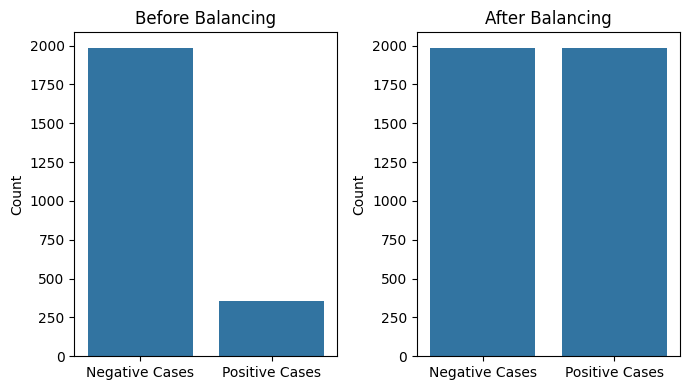

In [8]:
num_before = dict(Counter(y_train))
num_after = dict(Counter(y_train_smote))

labels = ['Negative Cases', 'Positive Cases']
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

sns.barplot(x=labels, y=list(num_before.values()), ax=axes[0])
axes[0].set_title('Before Balancing')
axes[0].set_ylabel('Count')

sns.barplot(x=labels, y=list(num_after.values()), ax=axes[1])
axes[1].set_title('After Balancing')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
Counter(y_test)

Counter({0: 497, 1: 89})

### Feature Scaling

In [11]:
X_train.dtypes.to_dict()

{'age': dtype('int64'),
 'education': dtype('float64'),
 'sex': dtype('int64'),
 'cigsPerDay': dtype('float64'),
 'BPMeds': dtype('float64'),
 'prevalentStroke': dtype('int64'),
 'prevalentHyp': dtype('int64'),
 'diabetes': dtype('int64'),
 'totChol': dtype('float64'),
 'sysBP': dtype('float64'),
 'diaBP': dtype('float64'),
 'BMI': dtype('float64'),
 'heartRate': dtype('float64'),
 'glucose': dtype('float64')}

In [15]:
from sklearn.preprocessing import StandardScaler

numerics = [
    'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

X_train_smote_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_smote_scaled[numerics] = scaler.fit_transform(X_train_smote[numerics])
X_test_scaled[numerics] = scaler.transform(X_test[numerics])

In [17]:
pd.DataFrame(X_test_scaled, columns=X_test.columns).sample(10)

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
id,,,,,,,,,,,,,,
1328,1.531353,3.0,1,-0.801539,0.0,0,0,0,-0.261158,-1.304430,-0.923044,0.190232,0.687634,-0.241689
1079,-0.646469,1.0,1,2.503593,0.0,0,0,0,-0.674684,0.691392,0.517403,0.061607,1.039607,-0.064256
2979,-1.735380,2.0,0,-0.057884,0.0,0,0,0,-1.218798,-0.897120,-0.650527,-0.619348,0.775628,-0.135229
2020,-0.404488,3.0,0,-0.057884,0.0,0,1,0,0.544131,0.732123,1.218161,0.467659,-0.104304,0.006718
2933,0.321452,1.0,1,-0.801539,0.0,0,0,0,-1.349386,-1.385892,-0.884113,-1.254907,-1.424201,0.006718
171,1.652344,1.0,0,-0.801539,0.0,0,1,0,0.239427,1.730034,2.308229,1.125916,1.215593,0.113178
847,-0.888449,1.0,1,0.437885,0.0,0,1,0,0.718247,0.528467,0.828851,-0.137635,-0.104304,-0.490095
1191,0.321452,3.0,0,-0.801539,0.0,0,1,0,0.370014,0.447005,0.673127,-1.386054,-0.192297,0.397071
1511,2.015314,3.0,0,0.851027,0.0,0,1,0,0.370014,0.854316,0.750989,1.420997,0.335662,0.006718


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier